# VQ-VAE Oncology Profile Generation

This notebook runs the VQ-VAE oncology inference workflow using the cohort daily-summary input table and trained VQ-VAE checkpoints. It preserves the observed missingness mask, generates the complete profile pickle for all VQ-VAE modes, and displays A0 example figures.


In [8]:
from pathlib import Path
import sys

from IPython.display import Image, display
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "scripts").exists():
    ROOT = ROOT.parent
if not (ROOT / "scripts").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from scripts.vqvae import constants as c
from scripts.vqvae.data import load_scaler_params
from scripts.vqvae.inference import generate_profiles, load_models, make_loader, save_profiles
from scripts.vqvae.plots import plot_embedding_probabilities, plot_signals

DATA_DIR = ROOT / "data" / "daily_summaries"
RESULTS_DIR = ROOT / "results" / "vq-vae"
FIGURES_DIR = RESULTS_DIR / "figures"
OUTPUT_PKL = ROOT / "data" / "output_vq_vae"/"profiles_per_sample_oncology.pkl"
DISPLAY_MODEL = "a0"


## 1. Load the Input Data

The workflow starts from the daily-summary input table used by the VQ-VAE.


In [2]:
input_data = pd.read_csv(c.DEFAULT_DATA_CSV, parse_dates=["date_time"])
summary = pd.DataFrame([{
    "rows": len(input_data),
    "patients": input_data["user"].nunique(),
    "first_date": input_data["date_time"].min().date(),
    "last_date": input_data["date_time"].max().date(),
}])

display(summary)
display(input_data.head(3))
assert input_data["user"].nunique() == 175

,rows,patients,first_date,last_date
0,51400,175,2023-02-16,2025-10-16


,user,date_time,service,sleep_start,location_distance,location_time_home,sleep_duration,activity_walking,app_usage_total,location_clusters_count,steps_steps_total,weekend,practiced_sport
0,11001,2023-04-19,PMP_FUENLABRADA,NaN,29833.074458,NaN,NaN,4775.0,7372.0,NaN,9237.0,0,1
1,11001,2023-04-20,PMP_FUENLABRADA,16800.0,7678.049816,780.0,17280.0,1172.0,12284.0,2.0,8937.0,0,1
2,11001,2023-04-21,PMP_FUENLABRADA,-7560.0,9686.270037,960.0,37620.0,666.0,8627.0,2.0,7345.0,0,0


## 2. Preprocess for VQ-VAE Inference

Preprocessing selects the model columns, clips out-of-range values, builds continuous patient-day sequences, applies the stored scaler, and creates the mask tensors used by the VQ-VAE.

In [3]:
loader, dataset = make_loader(
    c.DEFAULT_DATA_CSV,
    c.DEFAULT_SCALER,
)
first_batch = next(iter(loader))
lengths = [dataset[i]["length"] for i in range(len(dataset))]
preprocess_summary = pd.DataFrame([{
    "patients": len(dataset),
    "expanded_rows": len(dataset.dataset),
    "min_sequence_length": min(lengths),
    "max_sequence_length": max(lengths),
    "batch_signal_shape": tuple(first_batch["input"]["signal_imp"].shape),
}])
display(preprocess_summary)
assert len(dataset) == 175

,patients,expanded_rows,min_sequence_length,max_sequence_length,batch_signal_shape
0,175,51802,7,940,"(16, 10, 877)"


## 3. Load the VQ-VAE Checkpoints

All checkpoints are loaded because the profile pickle contains A0, A1, and A2 outputs.

In [4]:
models = load_models(c.DEFAULT_MODELS_DIR, device="cpu")
checkpoint_summary = pd.DataFrame([
    {"mode": mode.upper(), "parameters": sum(param.numel() for param in model.parameters())}
    for mode, model in models.items()
])
display(checkpoint_summary)
assert set(models) == {"a0", "a1", "a2"}

,mode,parameters
0,A0,43260
1,A1,61320
2,A2,64530


## 4. Encode and Quantize the Patient Sequences

The preprocessed sequences are passed through the VQ-VAE encoder and vector quantizer. The in-memory result contains the embedding indices and nearest-codebook metadata that will be written to the profile pickle in the final step.


In [5]:
profiles, plot_data, dataset = generate_profiles(
    data_csv=c.DEFAULT_DATA_CSV,
    models_dir=c.DEFAULT_MODELS_DIR,
    scaler_path=c.DEFAULT_SCALER,
    output_path=None,
    device="cpu",
    return_reconstructions=True,
)

assert set(profiles) == {"a0", "a1", "a2"}
for mode in profiles:
    assert sorted(profiles[mode]) == [5, 10, 15, 20, 25, 30]
    assert len(profiles[mode][30]) == 175

example_patient = int(dataset.indices[0])
length, quantized_indices, *_ = profiles[DISPLAY_MODEL][30][example_patient][0]
quantized_summary = pd.DataFrame([{
    "display_model": DISPLAY_MODEL.upper(),
    "example_patient": example_patient,
    "sequence_length": int(length),
    "unique_embeddings": int(np.unique(quantized_indices[:length]).size),
    "profile_pickle_to_write": str(OUTPUT_PKL.relative_to(ROOT)),
}])
display(quantized_summary)

,display_model,example_patient,sequence_length,unique_embeddings,profile_pickle_to_write
0,A0,11001,877,131,data/output_vq_vae


## 5. Inspect A0 Reconstructions and Embedding Usage

The full profile pickle has all modes. The figures below display A0 only: one reconstruction/imputation example and normalized embedding-usage probabilities for two patients.


results/vq-vae/figures/embeddings/embedding_probabilities_a0_example.png
results/vq-vae/figures/embeddings/embedding_probabilities_a0_example.csv
results/vq-vae/figures/reconstructions/patient_11001_feature_Sleep_Start.png
results/vq-vae/figures/reconstructions/patient_11001_feature_Sleep_Start.csv


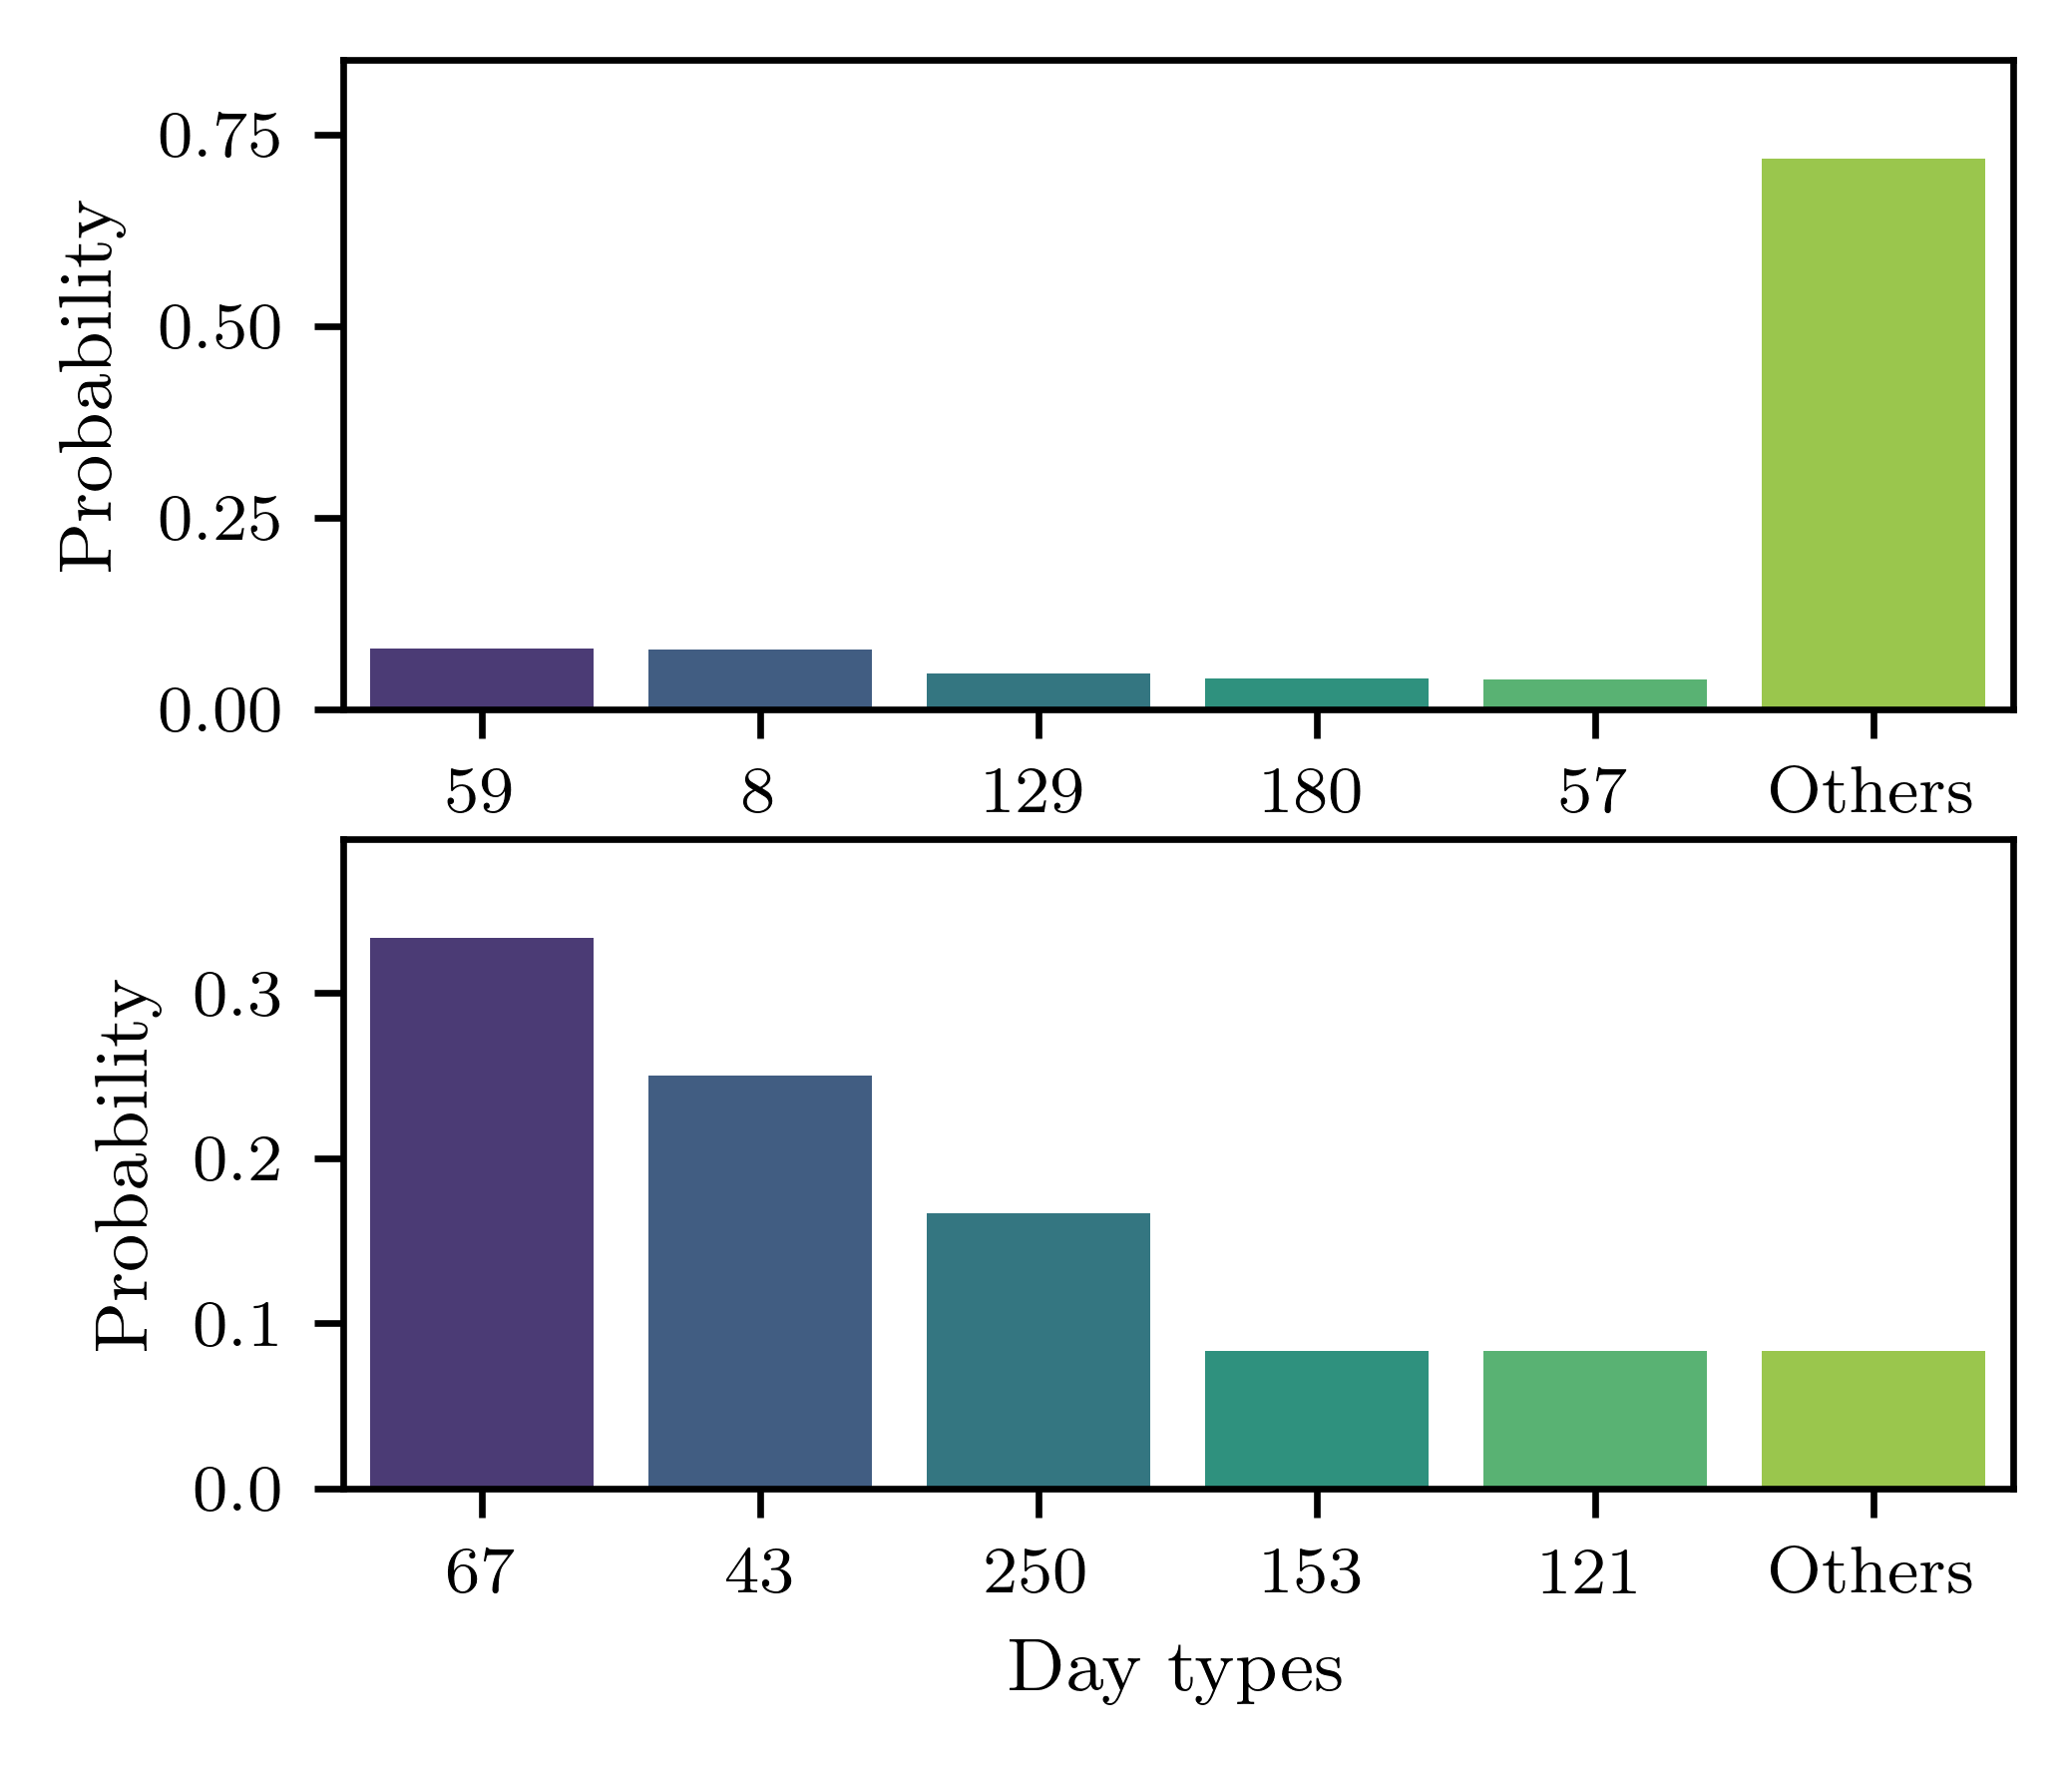

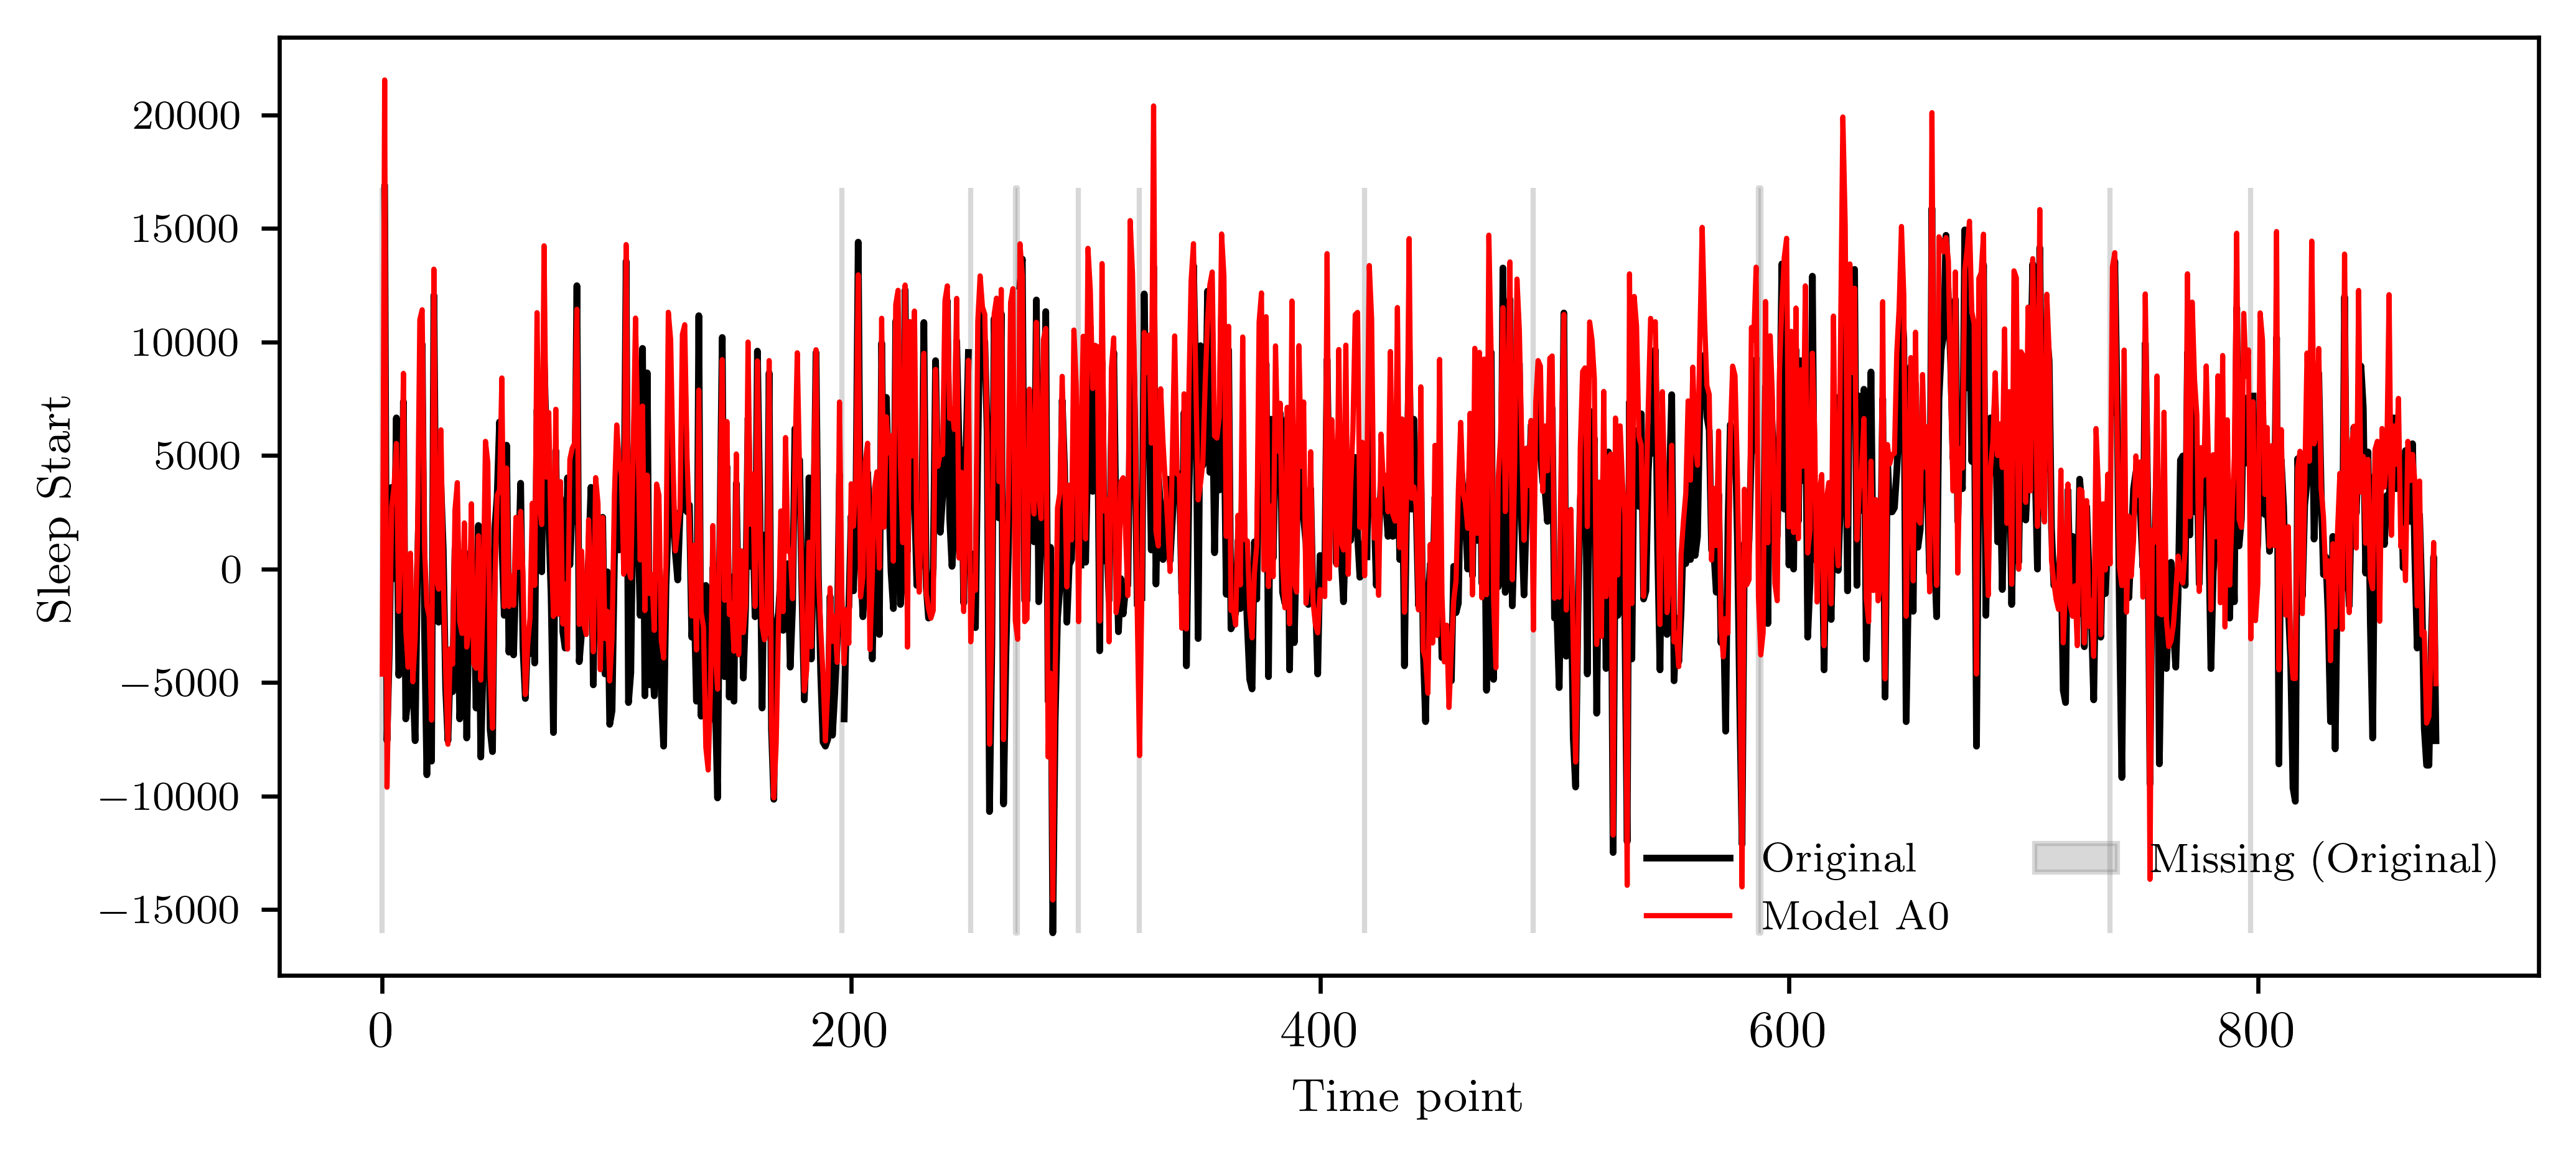

In [6]:
patient_ids = [int(dataset.indices[0]), int(dataset.indices[99])]
embedding_records = []
for patient_id in patient_ids:
    length, indices, *_ = profiles[DISPLAY_MODEL][30][patient_id][0]
    embedding_records.append({
        "indices": indices,
        "patient_id": patient_id,
        "model": DISPLAY_MODEL,
        "length": length,
        "top_n": 5,
    })

embedding_paths = plot_embedding_probabilities(
    embedding_records,
    output_dir=FIGURES_DIR / "embeddings",
    filename_prefix=f"embedding_probabilities_{DISPLAY_MODEL}_example",
    top_n=5,
)

patient_id = patient_ids[0]
row = int(np.where(plot_data["users"] == patient_id)[0][0])
model_idx = plot_data["model_names"].index(DISPLAY_MODEL)
scaler_params = load_scaler_params(c.DEFAULT_SCALER)
signal_paths = plot_signals(
    plot_data["original"][row:row + 1],
    [plot_data["reconstructions"][model_idx][row:row + 1]],
    plot_data["masks"][row:row + 1],
    plot_data["lengths"][row:row + 1],
    plot_data["users"][row:row + 1],
    feature_idx=0,
    model_names=[DISPLAY_MODEL],
    output_dir=FIGURES_DIR / "reconstructions",
    scaler_params=scaler_params,
    selected_test=True,
)

print(embedding_paths["figures"]["png"].relative_to(ROOT))
print(embedding_paths["data"]["csv"].relative_to(ROOT))
print(signal_paths[0]["figures"]["png"].relative_to(ROOT))
print(signal_paths[0]["data"]["csv"].relative_to(ROOT))
display(Image(filename=str(embedding_paths["figures"]["png"])))
display(Image(filename=str(signal_paths[0]["figures"]["png"])))

## 6. Generate and Confirm the Profile Pickle

The profile object is saved in the downstream pickle structure after the model outputs have been inspected.


In [9]:
save_profiles(profiles, OUTPUT_PKL)
artifact_summary = pd.DataFrame([
    {"artifact": "generated_profile_pickle", "path": str(OUTPUT_PKL.relative_to(ROOT))},
])
display(artifact_summary)

,artifact,path
0,generated_profile_pickle,data/output_vq_vae/profiles_per_sample_oncolog...
